In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (classification_report, roc_auc_score,confusion_matrix, roc_curve, f1_score)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import optuna
import joblib
import warnings
import sys
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

if 'src.config' in sys.modules:
    del sys.modules['src.config']
sys.path.append('../')
from src.config import *

print("Imports done")

Imports done


Loading

In [2]:
X_train= pd.read_csv('../data/X_train.csv')
y_train= pd.read_csv('../data/y_train.csv').squeeze()  
X_test= pd.read_csv('../data/X_test.csv')
y_test= pd.read_csv('../data/y_test.csv').squeeze()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (246008, 113)
y_train shape: (246008,)
X_test shape: (61503, 113)
y_test shape: (61503,)


Handeling Imbalanced data

In [3]:
smte=SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smte.fit_resample(X_train, y_train)
print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {y_train_sm.value_counts().to_dict()}")
print(f"New training shape: {X_train_sm.shape}")


Before SMOTE: {0: 226148, 1: 19860}
After SMOTE:  {0: 226148, 1: 226148}
New training shape: (452296, 113)


Baseline

In [ ]:
Baseline_model=XGBClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    eval_metric='auc',
    device='cpu'
)
Baseline_model.fit(X_train, y_train)
y_pred=Baseline_model.predict(X_test)
y_pred_proba=Baseline_model.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred))
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.46      0.04      0.07      4965

    accuracy                           0.92     61503
   macro avg       0.69      0.52      0.51     61503
weighted avg       0.88      0.92      0.89     61503

ROC AUC: 0.7568


Fine_Tuning with Optuna (Fixed - SMOTE inside CV to prevent leakage)

In [10]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos  

In [11]:
def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0, 5),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0, 2),
        'scale_pos_weight':  scale_pos_weight,  
        'random_state':      RANDOM_STATE,
        'eval_metric':       'auc',
        'device':            'cpu'
    }
    model = XGBClassifier(**params)
    scores=cross_val_score(model, X_train_sm, y_train_sm, cv=3, scoring='roc_auc')
    return scores.mean()
study=optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"\nBest AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")


Best AUC: 0.9721
Best params: {'n_estimators': 332, 'max_depth': 8, 'learning_rate': 0.04314560304666848, 'subsample': 0.6025914926726289, 'colsample_bytree': 0.9833865463296483, 'min_child_weight': 9, 'gamma': 0.04518368964404455, 'reg_alpha': 1.4442560113386376, 'reg_lambda': 1.1792944299244668}


Train Best Model 

In [12]:

xgb_tuned = XGBClassifier(
    **study.best_params,
    random_state=RANDOM_STATE,
    eval_metric='auc',
    device='cpu'
)
xgb_tuned.fit(X_train_sm, y_train_sm)

# Evaluate on test set
y_pred_tuned = xgb_tuned.predict(X_test)
y_pred_proba_tuned = xgb_tuned.predict_proba(X_test)[:,1]

print("=== TUNED MODEL TEST SET RESULTS ===")
print(classification_report(y_test, y_pred_tuned))
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba_tuned):.4f}")

=== TUNED MODEL TEST SET RESULTS ===
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.52      0.03      0.05      4965

    accuracy                           0.92     61503
   macro avg       0.72      0.51      0.50     61503
weighted avg       0.89      0.92      0.88     61503

ROC AUC: 0.7621


In [13]:
from sklearn.metrics import f1_score
thresholds = np.arange(0.1, 0.5, 0.01)
best_thresh = 0.5
best_f1 = 0

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba_tuned >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_thresh, pos_label=1)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"Default threshold (0.5) F1 for defaulters: {f1_score(y_test, y_pred, pos_label=1):.4f}")
print(f"Best threshold found: {best_thresh:.2f}")
print(f"Best F1 for defaulters: {best_f1:.4f}")

Default threshold (0.5) F1 for defaulters: 0.0429
Best threshold found: 0.16
Best F1 for defaulters: 0.3094


2nd approch

In [3]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Negative samples (repaid):   {neg:,}")
print(f"Positive samples (defaulted): {pos:,}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")


Negative samples (repaid):   226,148
Positive samples (defaulted): 19,860
scale_pos_weight: 11.39


In [ ]:
baseline = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric='auc',
    device='cpu'
)

baseline.fit(X_train, y_train)  
y_proba_base = baseline.predict_proba(X_test)[:, 1]

print("=== BASELINE RESULTS ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_base):.4f}")
print(classification_report(y_test, baseline.predict(X_test),
                            target_names=['Repaid','Defaulted']))

=== BASELINE RESULTS ===
AUC-ROC: 0.7545
              precision    recall  f1-score   support

      Repaid       0.96      0.75      0.84     56538
   Defaulted       0.18      0.62      0.28      4965

    accuracy                           0.74     61503
   macro avg       0.57      0.69      0.56     61503
weighted avg       0.89      0.74      0.80     61503



In [5]:
def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0, 2),
        'scale_pos_weight': scale_pos_weight, 
        'random_state':     RANDOM_STATE,
        'eval_metric':      'auc',
        'device':           'cpu'
    }

    model = XGBClassifier(**params)

    scores = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring='roc_auc', n_jobs=-1
    )
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest AUC (on REAL imbalanced data): {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best AUC (on REAL imbalanced data): 0.7648
Best params: {'n_estimators': 396, 'max_depth': 3, 'learning_rate': 0.13195326136659155, 'subsample': 0.935350283414323, 'colsample_bytree': 0.9642402983501384, 'min_child_weight': 9, 'gamma': 3.5142118836727283, 'reg_alpha': 1.7847751550867053, 'reg_lambda': 1.2433937415569585}


In [6]:
best_params = study.best_params
best_params['scale_pos_weight'] = scale_pos_weight
best_params['random_state']     = RANDOM_STATE
best_params['eval_metric']      = 'auc'
best_params['device']           = 'cpu'

best_model = XGBClassifier(**best_params)
best_model.fit(X_train, y_train)  

y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred  = best_model.predict(X_test)

print("=== TUNED MODEL RESULTS ===")
print(classification_report(y_test, y_pred,
                            target_names=['Repaid','Defaulted']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

=== TUNED MODEL RESULTS ===
              precision    recall  f1-score   support

      Repaid       0.96      0.72      0.82     56538
   Defaulted       0.18      0.68      0.28      4965

    accuracy                           0.72     61503
   macro avg       0.57      0.70      0.55     61503
weighted avg       0.90      0.72      0.78     61503

AUC-ROC: 0.7699


In [9]:
thresholds = np.arange(0.1, 0.6, 0.01)
best_thresh, best_f1 = 0.5, 0

for thresh in thresholds:
    y_pred_t = (y_proba >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_t, pos_label=1)
    if f1 > best_f1:
        best_f1   = f1
        best_thresh = thresh

print(f"Best threshold: {best_thresh:.2f}")
print(f"Best F1 for defaulters: {best_f1:.4f}")

y_pred_final = (y_proba >= best_thresh).astype(int)
print("\n=== FINAL RESULTS WITH TUNED THRESHOLD ===")
print(classification_report(y_test, y_pred_final,
                            target_names=['Repaid','Defaulted']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

Best threshold: 0.59
Best F1 for defaulters: 0.3090

=== FINAL RESULTS WITH TUNED THRESHOLD ===
              precision    recall  f1-score   support

      Repaid       0.95      0.82      0.88     56538
   Defaulted       0.21      0.56      0.31      4965

    accuracy                           0.80     61503
   macro avg       0.58      0.69      0.60     61503
weighted avg       0.89      0.80      0.84     61503

AUC-ROC: 0.7699


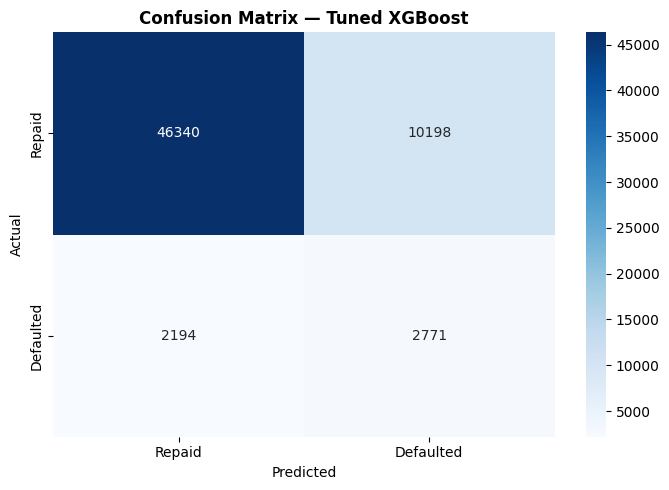

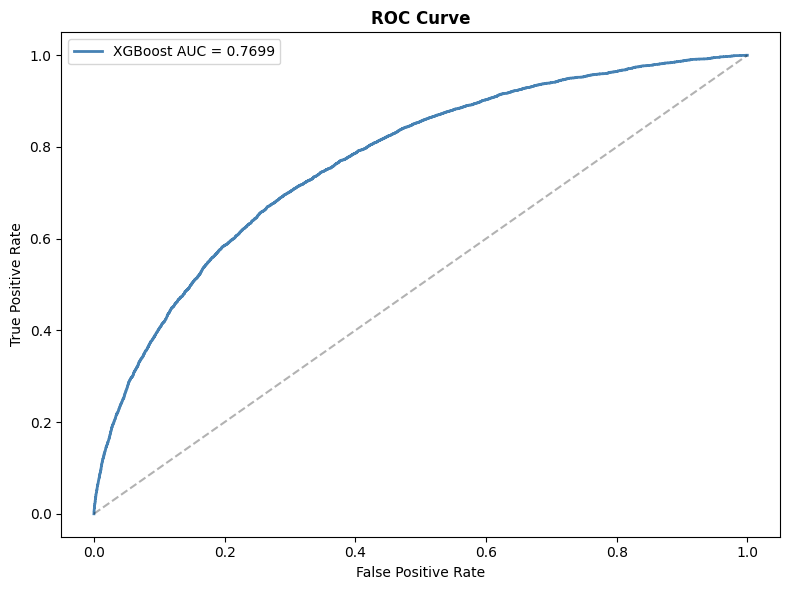

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Repaid','Defaulted'],
            yticklabels=['Repaid','Defaulted'])
plt.title('Confusion Matrix — Tuned XGBoost', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,label=f'XGBoost AUC = {roc_auc_score(y_test, y_proba):.4f}')
plt.plot([0,1],[0,1],'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/roc_curve.png', dpi=150)
plt.show()

In [11]:
joblib.dump(best_model,   '../models/xgboost_model.joblib')
joblib.dump(best_params,  '../models/best_params.joblib')
joblib.dump(best_thresh,  '../models/best_threshold.joblib')

print("Model saved.")
print(f"Final AUC:       {roc_auc_score(y_test, y_proba):.4f}")
print(f"Final threshold: {best_thresh:.2f}")
print(f"Final F1 (defaulters): {best_f1:.4f}")

Model saved.
Final AUC:       0.7699
Final threshold: 0.59
Final F1 (defaulters): 0.3090
